In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, datetime
import plotly.express as px

In [ ]:
cp=pd.read_csv("data/Project/car_prices.csv")
def parse_saledate(r):
    value=r['saledate'] 
    try:
        if isinstance(value, str):
            value = value.split(" (")[0]
        
        dt=pd.to_datetime(value, format="%a %b %d %Y %H:%M:%S GMT%z")
        return dt.month_name(),dt.month 
    except Exception:
        return float("nan")
cp[['saledate','month']]=cp.apply(parse_saledate,axis=1,result_type='expand') 
cp.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,month
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,December,12.0
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,December,12.0
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,January,1.0
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,January,1.0
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,December,12.0


In [ ]:
def revnum(x):
    x=str(x)
    if x.isnumeric():
        return np.nan
    return x
cp['color']=cp['color'].apply(revnum)
cp['body']=cp['body'].str.lower()
cp.dropna(inplace=True) 
cp.drop_duplicates(inplace=True) 

In [ ]:
cp.isna().sum() 

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
month           0
dtype: int64

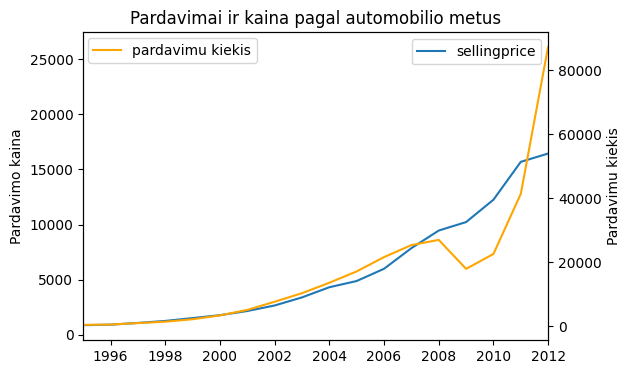

In [ ]:
vid_kaina=cp.groupby('year')['sellingprice'].mean().reset_index()
pard_kiekis=cp.groupby('year').count().reset_index() 

fix, axis=plt.subplots(figsize=[6,4])

ax=axis.twinx() 
vid_kaina.plot(x='year',ax=axis,label='vid. kaina',xlabel='',ylabel='Pardavimo kaina',title='Pardavimai ir kaina pagal automobilio metus')
pard_kiekis.plot(x='year',y='make',ax=ax,color='orange',label='pardavimu kiekis',ylabel='Pardavimu kiekis') 

ax.legend(loc=[0.01,0.9])
ax.set_xlim(1995,2012)

plt.show()

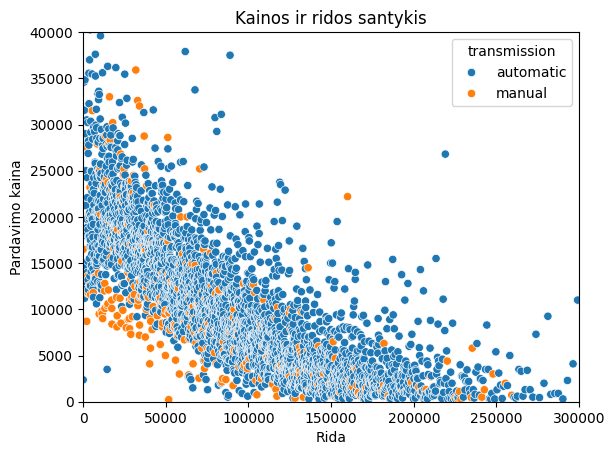

In [ ]:
rida=cp.groupby(['odometer','transmission'])['sellingprice'].mean().reset_index()


ax=sns.scatterplot(data=rida.iloc[::50,:],x='odometer',y='sellingprice',hue='transmission',) 

ax.set_xlim(0,300000)
ax.set_ylim(0,40000)
ax.set_title('Kainos ir ridos santykis')
ax.set_xlabel('Rida')
ax.set_ylabel('Pardavimo kaina')

plt.show()

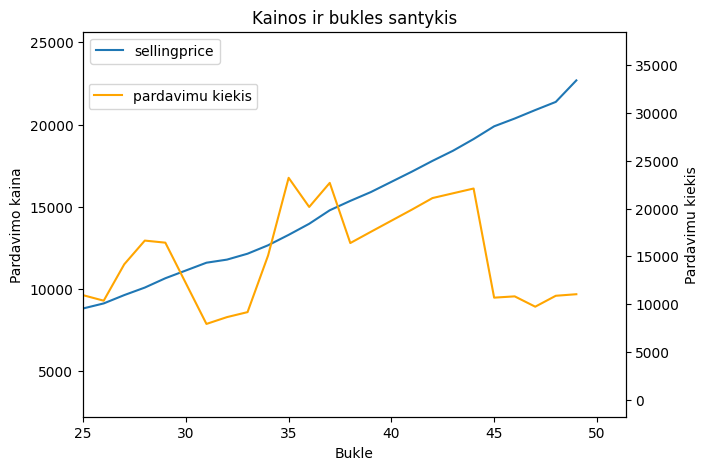

In [25]:
bukle=cp.groupby('condition')['sellingprice'].mean().reset_index()
kiekis=cp.groupby('condition').count().reset_index()

fix, axis=plt.subplots(figsize=[7,5])

ax=axis.twinx()

kiekis.plot(x='condition',y='make',ax=ax,color='orange',label='pardavimu kiekis',ylabel='Pardavimu kiekis')
axi=bukle.plot(x='condition',ax=axis,title='Kainos ir bukles santykis',xlabel='Bukle',ylabel='Pardavimo kaina')

axi.set_xlim(25)
axis.legend(loc='upper left')
ax.legend(loc=[0.01,0.8])

plt.show()

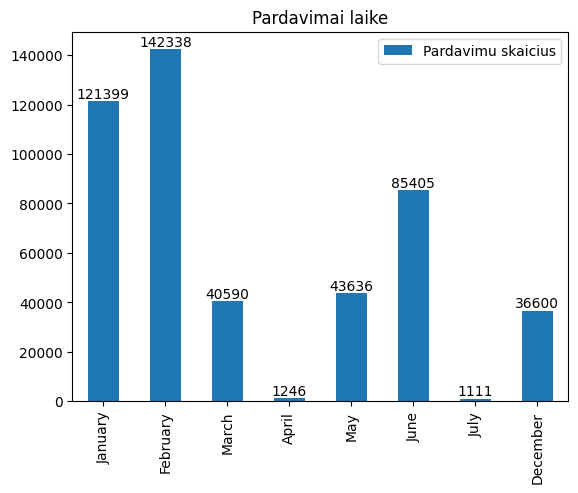

In [ ]:
pardavimai=cp.groupby(['saledate','month']).count().reset_index().sort_values(by='month') 

ax=pardavimai.plot(x='saledate',y='year',kind='bar',title='Pardavimai laike',xlabel='',label='Pardavimu skaicius')

for a in ax.containers: 
     ax.bar_label(a)

plt.show()

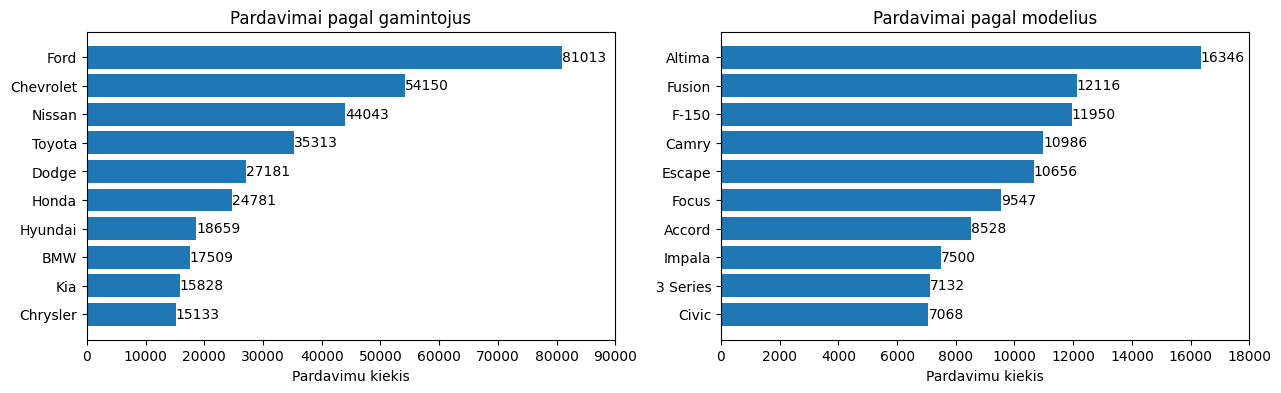

In [ ]:
gamintojai=cp.groupby('make').count().reset_index().sort_values(by='year',ascending=False).head(10) 
gamintojai=gamintojai.sort_values(by='year',ascending=True) 
make=gamintojai['make'].values
sales_ma=gamintojai['year'].values

modelis=cp.groupby('model').count().reset_index().sort_values(by='year',ascending=False).head(10)
modelis=modelis.sort_values(by='year',ascending=True)
model=modelis['model'].values
sales_mo=modelis['year'].values

fig,(left,right)=plt.subplots(1,2,figsize=[15,4])

ax=left.barh(make,sales_ma)
axis=right.barh(model,sales_mo)

left.bar_label(ax)
right.bar_label(axis)
left.set_xlim(0,90000)
right.set_xlim(0,18000)
left.set_xlabel("Pardavimu kiekis")
right.set_xlabel("Pardavimu kiekis")
left.set_title('Pardavimai pagal gamintojus')
right.set_title('Pardavimai pagal modelius')


plt.show()

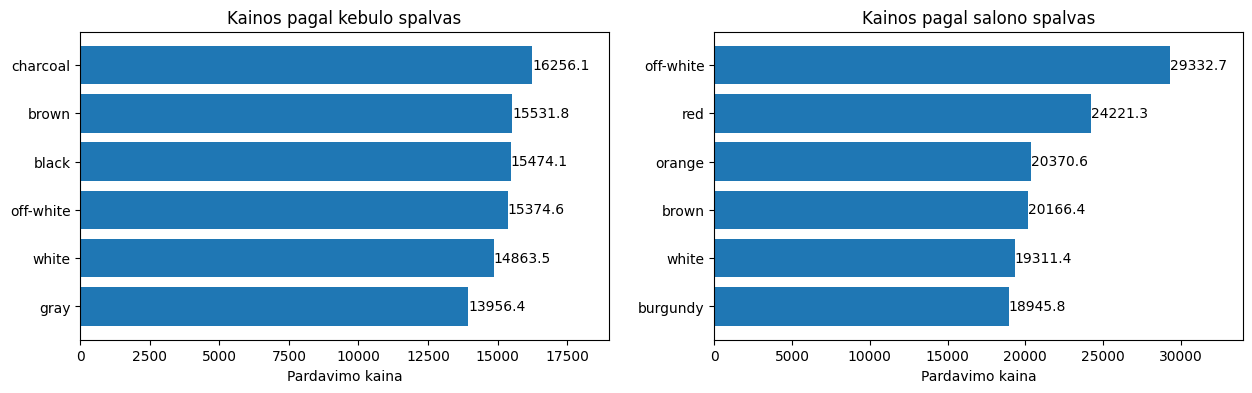

In [ ]:
spalvos=cp.query('color!="—"').groupby('color')['sellingprice'].mean().reset_index().sort_values(by='sellingprice',ascending=False).head(6)
spalvos=spalvos.sort_values(by='sellingprice',ascending=True)
color=spalvos['color'].values
avg_price_c=spalvos['sellingprice'].values

s_spalvos=cp.query('interior!="—"').groupby('interior')['sellingprice'].mean().reset_index().sort_values(by='sellingprice',ascending=False).head(6)
s_spalvos=s_spalvos.sort_values(by='sellingprice',ascending=True)
interior=s_spalvos['interior'].values
avg_price_i=s_spalvos['sellingprice'].values

fig,(left,right)=plt.subplots(1,2,figsize=[15,4]) 

ax=left.barh(color,avg_price_c)
axis=right.barh(interior,avg_price_i)

left.bar_label(ax)
right.bar_label(axis)
left.set_xlim(0,19000)
right.set_xlim(0,34000)
left.set_title('Kainos pagal kebulo spalvas')
right.set_title('Kainos pagal salono spalvas')
left.set_xlabel('Pardavimo kaina')
right.set_xlabel('Pardavimo kaina')


plt.show()

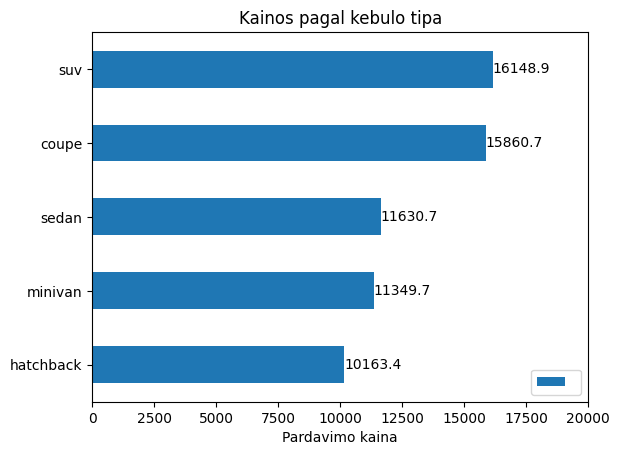

In [ ]:
bd=["suv","coupe","sedan","minivan","hatchback"] 
kebulas=cp.query(expr="`body` in @bd").groupby('body')['sellingprice'].mean().reset_index().sort_values(by='sellingprice',ascending=False) 
kebulas=kebulas.sort_values(by='sellingprice',ascending=True) 

ax=kebulas.plot(x='body',y='sellingprice',kind='barh',title='Kainos pagal kebulo tipa',ylabel='',label='')

for a in ax.containers:
    ax.bar_label(a)

ax.set_xlim(0,20000)
ax.set_xlabel('Pardavimo kaina')

plt.show()

In [ ]:
cp["state"] = cp["state"].str.upper()
states=cp['state'].value_counts()

fig=px.choropleth(
    states,
    locations=states.index,     
    locationmode="USA-states",  
    color=states.values,
    scope="usa",
    color_continuous_scale="blues",
    title="Pardavimai pagal valstijas"
)

fig.show()